# Identificarea dispozitivelor folosind baza de date DNS



In [37]:
import pandas as pd

df = pd.read_pickle("dns_dataset.pkl")

In [38]:
df.head()

,mac,domain,qtype,timestamp
0,c82d83a47e2f5fd4e028d3d0ce339d4a,54c900172974546e077fe41558669950,28,1760210536
1,c82d83a47e2f5fd4e028d3d0ce339d4a,e4eaf27a746230eb9247eb6cb1c507b4,1,1760210551
2,c82d83a47e2f5fd4e028d3d0ce339d4a,e4eaf27a746230eb9247eb6cb1c507b4,28,1760210551
3,c82d83a47e2f5fd4e028d3d0ce339d4a,0a39dc006dc326d654eaa9d2c878b567,1,1760210554
4,c82d83a47e2f5fd4e028d3d0ce339d4a,0a39dc006dc326d654eaa9d2c878b567,28,1760210554


In [39]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 584789 entries, 0 to 584788
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   mac        584789 non-null  object
 1   domain     584789 non-null  object
 2   qtype      584789 non-null  int64 
 3   timestamp  584789 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 17.8+ MB


# Creare token

Definim un „token DNS” ca fiind combinatia dintre domeniul interogat si tipul cererii.  
Astfel, pastram informatia despre *ce* este interogat și *cum* este interogat.


In [40]:
df["token"] = df["domain"] + "_" + df["qtype"].astype(str)
df.head()

,mac,domain,qtype,timestamp,token
0,c82d83a47e2f5fd4e028d3d0ce339d4a,54c900172974546e077fe41558669950,28,1760210536,54c900172974546e077fe41558669950_28
1,c82d83a47e2f5fd4e028d3d0ce339d4a,e4eaf27a746230eb9247eb6cb1c507b4,1,1760210551,e4eaf27a746230eb9247eb6cb1c507b4_1
2,c82d83a47e2f5fd4e028d3d0ce339d4a,e4eaf27a746230eb9247eb6cb1c507b4,28,1760210551,e4eaf27a746230eb9247eb6cb1c507b4_28
3,c82d83a47e2f5fd4e028d3d0ce339d4a,0a39dc006dc326d654eaa9d2c878b567,1,1760210554,0a39dc006dc326d654eaa9d2c878b567_1
4,c82d83a47e2f5fd4e028d3d0ce339d4a,0a39dc006dc326d654eaa9d2c878b567,28,1760210554,0a39dc006dc326d654eaa9d2c878b567_28


# Reprezentarea fiecarui dispozitiv

Toate interogarile DNS sunt agregate la nivel de dispozitiv.  

- pentru fiecare dispozitiv avem istoricul lui de interogari DNS (colectie de tokenuri), care descrie comportamentul sau de retea.


In [41]:
grouped = df.groupby("mac")["token"].apply(list)
grouped.head()

mac
1093ef9de22486f357396c5b0c37beb4    [0f5d0c8cfc3c0a4db4088ba07e9663e2_1, cde178516...
19b2ec9332c33b73e12691408646795b    [f5f3abdc619aa8e2161f29e4800b2d07_1, f5f3abdc6...
20979bf8e363e1bae629cdb88fd16668    [b98740041a017d7e610a7e85d64d6226_1, b98740041...
20bf46bf76672bb70f9ab950cf8683fe    [cf9a80e13d00753200bcb3d3ec575f58_1, 5d2afc3f7...
3696c9ac3bd67ac15243a7cd8d87311c    [fa6ee44012e47198281fa6fcb1d15ba4_1, d103cf2a2...
Name: token, dtype: object

# Transformare in documente 

Transformam comportamentul unui dispozitiv intr-un „text” artificial.

Pentru a putea aplica tehnici de tip TF-IDF, fiecare profil de dispozitiv este transformat intr-un sir de caractere.  

In aceasta reprezentare:
- fiecare dispozitiv devine un „document”
- fiecare token DNS devine un „cuvant”


In [42]:
documents = grouped.apply(lambda x: " ".join(x))
documents.head()


mac
1093ef9de22486f357396c5b0c37beb4    0f5d0c8cfc3c0a4db4088ba07e9663e2_1 cde1785164e...
19b2ec9332c33b73e12691408646795b    f5f3abdc619aa8e2161f29e4800b2d07_1 f5f3abdc619...
20979bf8e363e1bae629cdb88fd16668    b98740041a017d7e610a7e85d64d6226_1 b98740041a0...
20bf46bf76672bb70f9ab950cf8683fe    cf9a80e13d00753200bcb3d3ec575f58_1 5d2afc3f70c...
3696c9ac3bd67ac15243a7cd8d87311c    fa6ee44012e47198281fa6fcb1d15ba4_1 d103cf2a206...
Name: token, dtype: object

# Amprenta dispozitivului

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(min_df=5)
X = vectorizer.fit_transform(documents)

X.shape


(32, 708)


Matricea TF-IDF obtinuta are dimensiunea (32, 708), ceea ce inseamna ca setul de date conține 32 de dispozitive distincte, fiecare descris prin 708 caracteristici comportamentale extrase din traficul DNS.


# Cosine similarity

Dupa ce avem amprentele numerice ale dispozitivelor, urmatorul pas este sa masuram cat de asemanatoare sunt intre ele. 
Daca doua dispozitive au tipare DNS similare, vectorii lor TF-IDF vor fi apropiați.


In [44]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(X)
similarity.shape


(32, 32)

- heatmap al matricei de similaritate intre device-uri

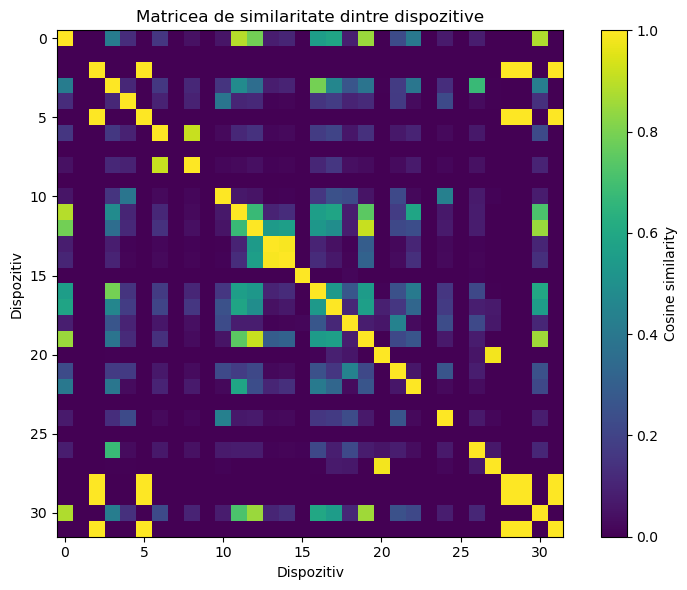

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.imshow(similarity)
plt.colorbar(label="Cosine similarity")
plt.title("Matricea de similaritate dintre dispozitive")
plt.xlabel("Dispozitiv")
plt.ylabel("Dispozitiv")
plt.tight_layout()
plt.show()


# Redenumire deviceuri

In [46]:
unique_macs = df["mac"].unique()

device_map = {mac: f"Device {i+1}" for i, mac in enumerate(unique_macs)}

df["device"] = df["mac"].map(device_map)

df[["mac", "device"]].drop_duplicates().head()


,mac,device
0,c82d83a47e2f5fd4e028d3d0ce339d4a,Device 1
230413,20bf46bf76672bb70f9ab950cf8683fe,Device 2
294439,78e9b89f754ae8acfab695fc4bc138b0,Device 3
323569,827cfb595f6b4e6e92af99251070ed7f,Device 4
340016,c3624ed102742e9e727d737af14b1133,Device 5


- cat trafic produce fiecare dispozitiv?

In [47]:
traffic_per_device = df["device"].value_counts()


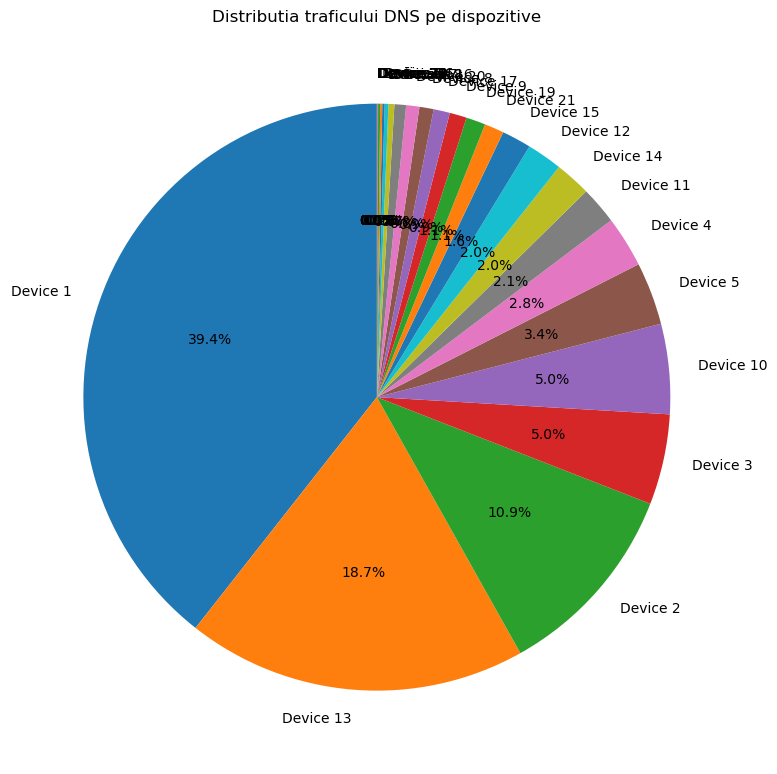

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.pie(traffic_per_device.values, labels=traffic_per_device.index, autopct='%1.1f%%', startangle=90)
plt.title("Distributia traficului DNS pe dispozitive")
plt.tight_layout()
plt.show()


# Identificare qtypeuri

In [49]:
df["qtype"].value_counts().sort_index()


qtype
1     333950
28    173183
65     77656
Name: count, dtype: int64

In [50]:
qtype_map = {
    1: "web_api_ipv4",
    28: "web_api_ipv6",
    65: "iot_service"
}

df["traffic_type"] = df["qtype"].map(qtype_map).fillna("other")


In [51]:
df["traffic_type"].value_counts()


traffic_type
web_api_ipv4    333950
web_api_ipv6    173183
iot_service      77656
Name: count, dtype: int64

# Distributia tipului de trafic pe device

In [52]:
traffic_per_device = df.groupby("device")["traffic_type"].value_counts(normalize=True).unstack().fillna(0)


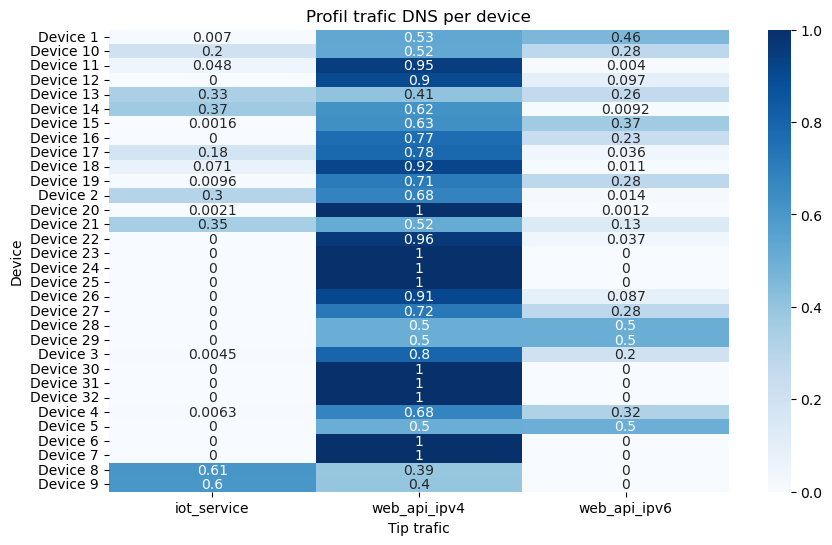

In [53]:
import seaborn as sns
plt.figure(figsize=(10,6))
sns.heatmap(traffic_per_device, annot=True, cmap="Blues")
plt.title("Profil trafic DNS per device")
plt.xlabel("Tip trafic")
plt.ylabel("Device")
plt.show()


# Feature importance

In [54]:
# token combinat: domain_qtype + traffic_type
df["token_extended"] = df["domain"] + "_" + df["qtype"].astype(str) + "_" + df["traffic_type"]

# agregam pe device
documents_extended = df.groupby("mac")["token_extended"].apply(lambda x: " ".join(x))


In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_ext = TfidfVectorizer(min_df=5)
X_ext = vectorizer_ext.fit_transform(documents_extended)

print(X_ext.shape)


(32, 708)


In [56]:
from sklearn.preprocessing import LabelEncoder

labels = LabelEncoder()
y = labels.fit_transform(documents_extended.index)


In [57]:
from sklearn.ensemble import RandomForestClassifier

# model
rf_ext = RandomForestClassifier(n_estimators=200, random_state=42)
rf_ext.fit(X_ext, y)

# scor (exploratoriu)
print("Accuracy (exploratory):", rf_ext.score(X_ext, y))

# feature importance
import pandas as pd

features_ext = vectorizer_ext.get_feature_names_out()
importances_ext = pd.Series(rf_ext.feature_importances_, index=features_ext)

# top 15 cele mai importante
top_features_ext = importances_ext.sort_values(ascending=False).head(15)
top_features_ext


Accuracy (exploratory): 0.75


b98740041a017d7e610a7e85d64d6226_1_web_api_ipv4    0.083250
7042fd4dd0ee4c8b7a17a78aa0f1f025_1_web_api_ipv4    0.033663
e284d2bea57dab138ca011caf40d12ee_1_web_api_ipv4    0.015605
3268535b813da9054767916ad304c431_1_web_api_ipv4    0.014845
bc569d6dac7e242c51a34ae34a5d6352_1_web_api_ipv4    0.013336
fdecdb399ae024ed5248d091fd22a412_1_web_api_ipv4    0.012077
e30df61d14e1c6d2aafe801d682dd921_1_web_api_ipv4    0.011664
037b2b72413b84385d6120b1f2a786d9_1_web_api_ipv4    0.009611
e30df61d14e1c6d2aafe801d682dd921_65_iot_service    0.009282
fe560eef3275d190e8ff5f8d4eb49b3b_1_web_api_ipv4    0.009143
ea309bd7a5b9209c48cbbeb2eb060e02_1_web_api_ipv4    0.008441
65f640869afa4748c4ef1332ae5848e3_1_web_api_ipv4    0.008422
5a0e50da1b58fd62d8102b7ce9af049f_1_web_api_ipv4    0.008344
0dfb6784f4d3f320a4d9b1992381e8ad_1_web_api_ipv4    0.008165
ea309bd7a5b9209c48cbbeb2eb060e02_65_iot_service    0.007974
dtype: float64

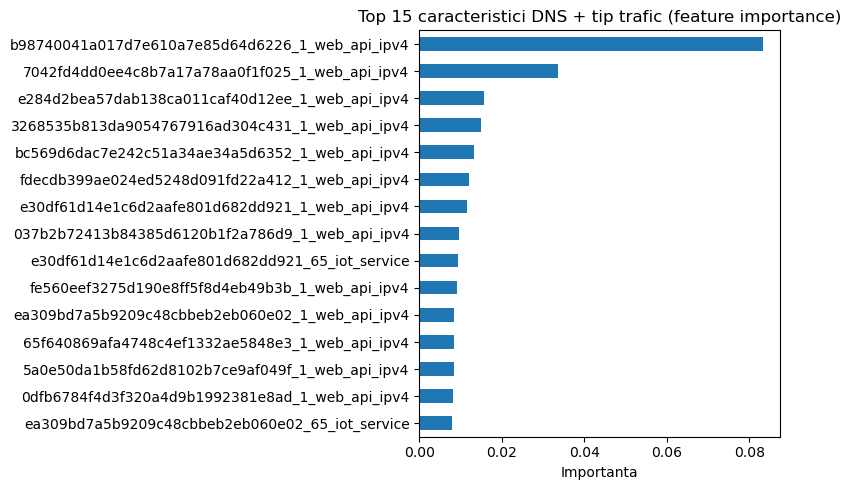

In [58]:
import matplotlib.pyplot as plt

top_features_ext.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Top 15 caracteristici DNS + tip trafic (feature importance)")
plt.xlabel("Importanta")
plt.tight_layout()
plt.show()


# Reidentificare cu trafic partial

In [59]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extragem lista unica de device-uri
unique_devices = sorted(df["device"].unique())
ref_docs = []
devices_actually_tested = []

for dev_name in unique_devices:
    df_dev = df[df["device"] == dev_name]
    
    if len(df_dev) < 10: 
        continue
    
    # Impartim traficul in doua
    half = len(df_dev) // 2
    part_ref = df_dev.iloc[:half]
    
    tokens_ref = (part_ref["domain"] + "_" + part_ref["qtype"].astype(str) + "_" + part_ref["traffic_type"]).tolist()
    ref_docs.append(" ".join(tokens_ref))
    devices_actually_tested.append(dev_name)

# matricea TF-IDF
X_reference = vectorizer_ext.transform(ref_docs)

# 2. Test
similarity_results = []
correct = 0

for i, dev_name in enumerate(devices_actually_tested):
    df_dev = df[df["device"] == dev_name]
    half = len(df_dev) // 2
    part_test = df_dev.iloc[half:]
    
    tokens_test = (part_test["domain"] + "_" + part_test["qtype"].astype(str) + "_" + part_test["traffic_type"]).tolist()
    doc_test = " ".join(tokens_test)
    
    vec_test = vectorizer_ext.transform([doc_test])
    sims = cosine_similarity(vec_test, X_reference)[0]
    
    predicted_device = devices_actually_tested[sims.argmax()]
    if predicted_device == dev_name:
        correct += 1
        
    similarity_results.append(sims)

print(f"Acuratete finala: {correct / len(devices_actually_tested):.2%}")

Acuratete finala: 74.07%



--- Analiza Confuziilor (Similitudine mare între device-uri diferite) ---
ATENȚIE: Device 11 seamănă foarte mult cu Device 20 (Scor: 0.8899)
ATENȚIE: Device 12 seamănă foarte mult cu Device 27 (Scor: 0.9190)
ATENȚIE: Device 15 seamănă foarte mult cu Device 4 (Scor: 0.9809)
ATENȚIE: Device 17 seamănă foarte mult cu Device 2 (Scor: 0.8028)
ATENȚIE: Device 18 seamănă foarte mult cu Device 20 (Scor: 0.8467)
ATENȚIE: Device 23 seamănă foarte mult cu Device 24 (Scor: 1.0000)
ATENȚIE: Device 26 seamănă foarte mult cu Device 20 (Scor: 0.9066)
ATENȚIE: Device 3 seamănă foarte mult cu Device 26 (Scor: 0.8774)
ATENȚIE: Device 6 seamănă foarte mult cu Device 23 (Scor: 1.0000)
ATENȚIE: Device 8 seamănă foarte mult cu Device 9 (Scor: 0.8742)


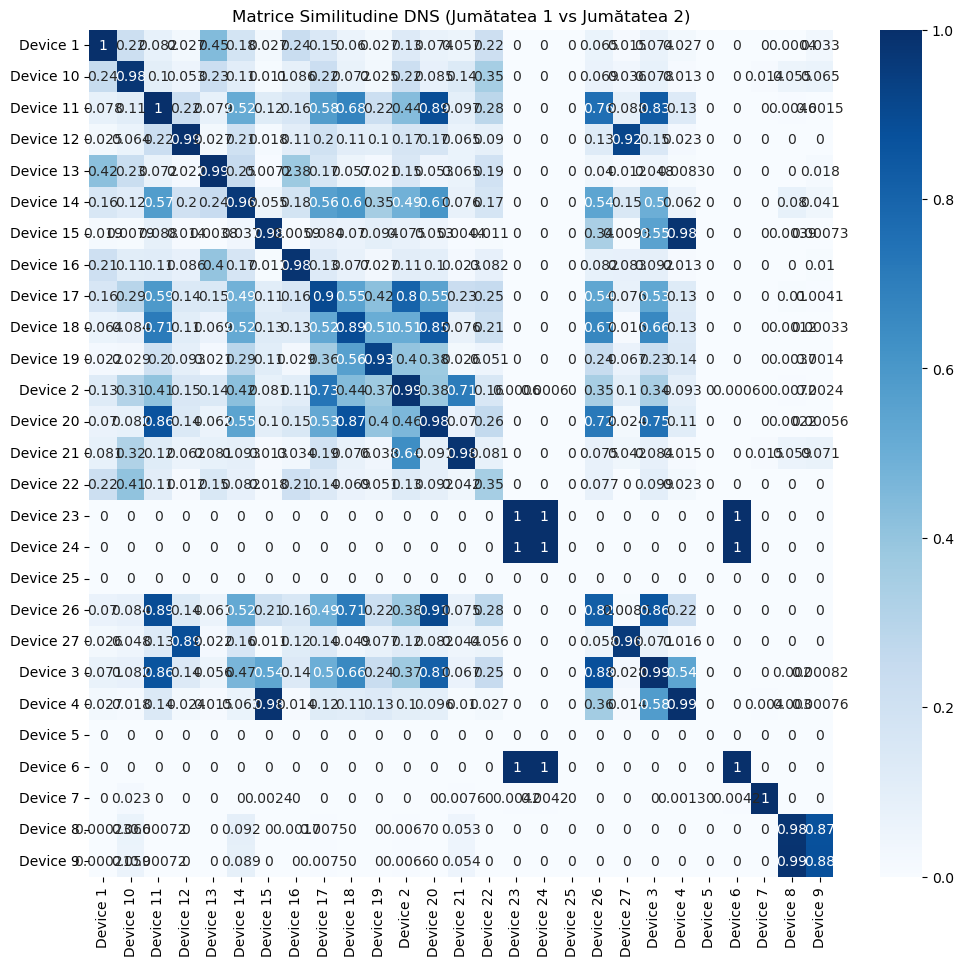

In [60]:
sim_matrix = np.array(similarity_results)

print("\n--- Analiza Confuziilor (Similitudine mare între device-uri diferite) ---")

seen_pairs = set()  # pentru a nu repeta inversul

for i, dev_name in enumerate(devices_actually_tested):
    current_sims = sim_matrix[i].copy()
    current_sims[i] = 0  # ignorăm diagonală
    
    best_match_idx = current_sims.argmax()
    best_score = current_sims[best_match_idx]
    
    if best_score > 0.70:
        # perechea sub forma de set, ca 26+3 și 3+26 sa fie acelasi
        pair = frozenset([dev_name, devices_actually_tested[best_match_idx]])
        if pair not in seen_pairs:
            print(f"ATENȚIE: {dev_name} seamănă foarte mult cu {devices_actually_tested[best_match_idx]} (Scor: {best_score:.4f})")
            seen_pairs.add(pair) 

# Vizualizare Heatmap
plt.figure(figsize=(12,11))
sns.heatmap(sim_matrix, annot=True, xticklabels=devices_actually_tested, yticklabels=devices_actually_tested, cmap="Blues")
plt.title("Matrice Similitudine DNS (Jumătatea 1 vs Jumătatea 2)")
plt.show()

# De ce seamana atat de mult ( 98% ) device 4 si device 15?

In [61]:
devices_check = ["Device 15", "Device 4"]

# grupare si calcul procent qtype
qtype_percent = (
    df[df["device"].isin(devices_check)]
    .groupby("device")["qtype"]
    .value_counts(normalize=True)  # procent din total
    .unstack(fill_value=0)         # qtype-uri pe coloane
)

print(qtype_percent)


qtype            1         28        65
device                                 
Device 15  0.628913  0.369501  0.001586
Device 4   0.676598  0.317079  0.006323


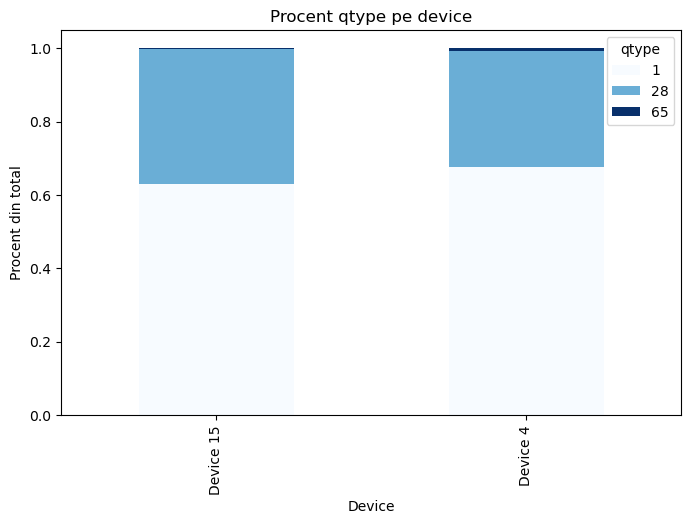

In [62]:
import matplotlib.pyplot as plt

qtype_percent.loc[devices_check].plot(kind="bar", stacked=True, figsize=(8,5), colormap="Blues")
plt.title("Procent qtype pe device")
plt.ylabel("Procent din total")
plt.xlabel("Device")
plt.legend(title="qtype")
plt.show()


In [63]:
# Analizăm perechile cu similitudine foarte mare (> 0.90)
high_sim_pairs = [
    ("Device 23", "Device 24"),
    ("Device 6", "Device 23"),
    ("Device 15", "Device 4"),
    ("Device 12", "Device 27")
]

for d1, d2 in high_sim_pairs:
    dom1 = set(df[df["device"] == d1]["domain"])
    dom2 = set(df[df["device"] == d2]["domain"])
    comune = dom1.intersection(dom2)
    
    print(f"\nAnaliză {d1} vs {d2}:")
    print(f" - Domenii comune: {len(comune)}")
    print(f" - Exemple domenii: {list(comune)[:5]}")


Analiză Device 23 vs Device 24:
 - Domenii comune: 3
 - Exemple domenii: ['d1d4d96e0344a4cf87b84f74392824c6', 'b98740041a017d7e610a7e85d64d6226', '69edbd5e2bee4a916dad9b22765e3d45']

Analiză Device 6 vs Device 23:
 - Domenii comune: 1
 - Exemple domenii: ['b98740041a017d7e610a7e85d64d6226']

Analiză Device 15 vs Device 4:
 - Domenii comune: 230
 - Exemple domenii: ['c7ac30a5dd43d4a10decb435c057a082', 'd3538ff15a33aa0cd16812878fa7a840', '213c0e5c196fcd6af9c416c7450954d7', '65f640869afa4748c4ef1332ae5848e3', 'e567811cdeb3b8e0f1e111772d898f52']

Analiză Device 12 vs Device 27:
 - Domenii comune: 17
 - Exemple domenii: ['72fea28a3d1b66ccb04514a3bbe63826', '846d41bcf9b4f0b4c27f20d0adf67084', '6eb7f7fefb5316d6ee2313b28bee9a40', '5a0e50da1b58fd62d8102b7ce9af049f', '1db2473d4935a36bfa1892afc81cf4e5']


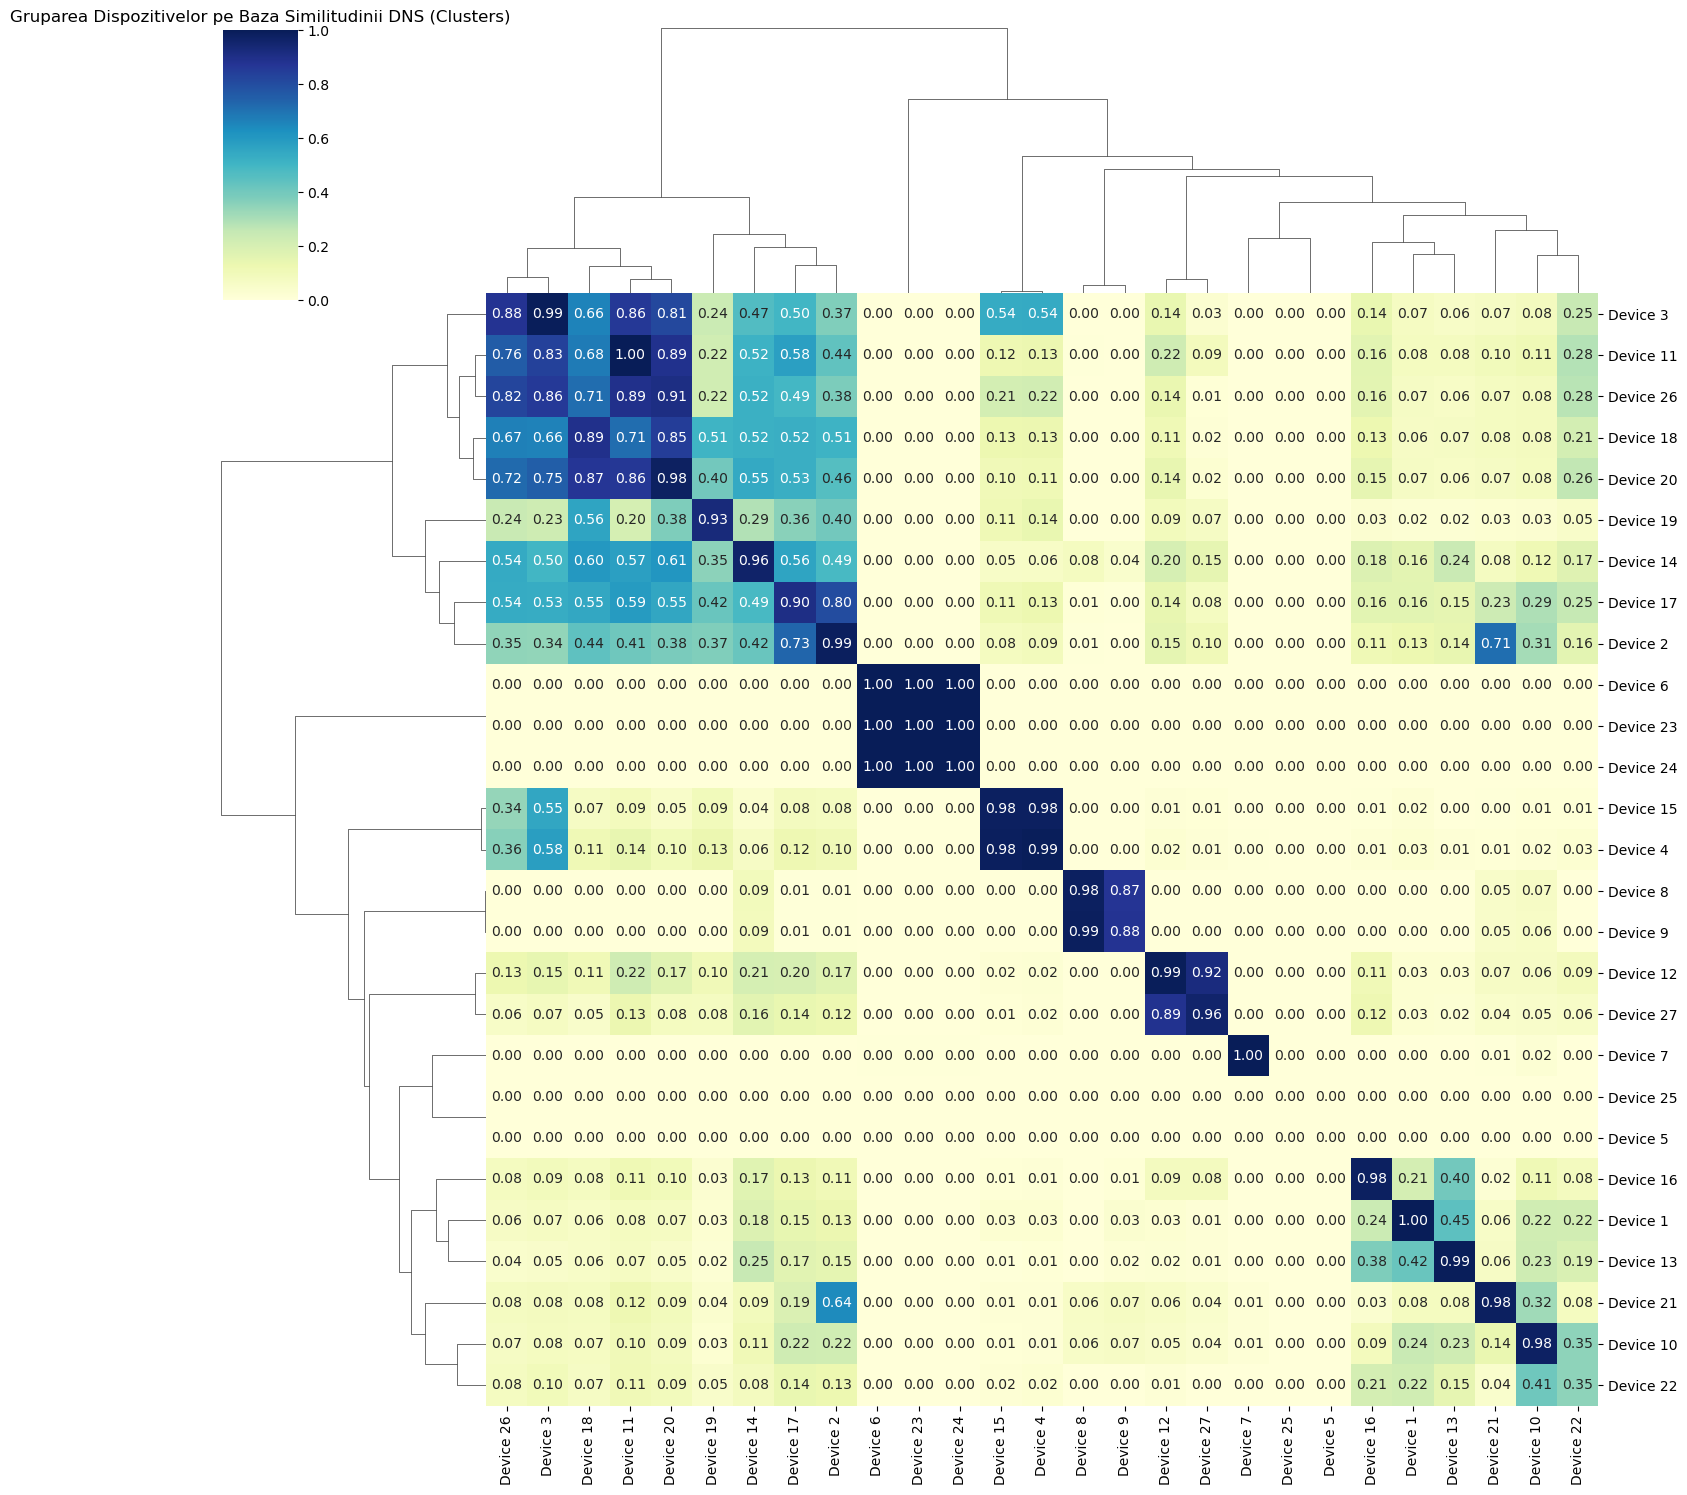

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# Transformam matricea intr-un DataFrame
df_sim = pd.DataFrame(sim_matrix, index=devices_actually_tested, columns=devices_actually_tested)

# Cream Clustermap-ul
g = sns.clustermap(
    df_sim, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    figsize=(15, 15),
    metric="euclidean", # Distanta intre profile
    method="ward"       # Metoda de grupare
)

plt.title("Gruparea Dispozitivelor pe Baza Similitudinii DNS (Clusters)")
plt.show()

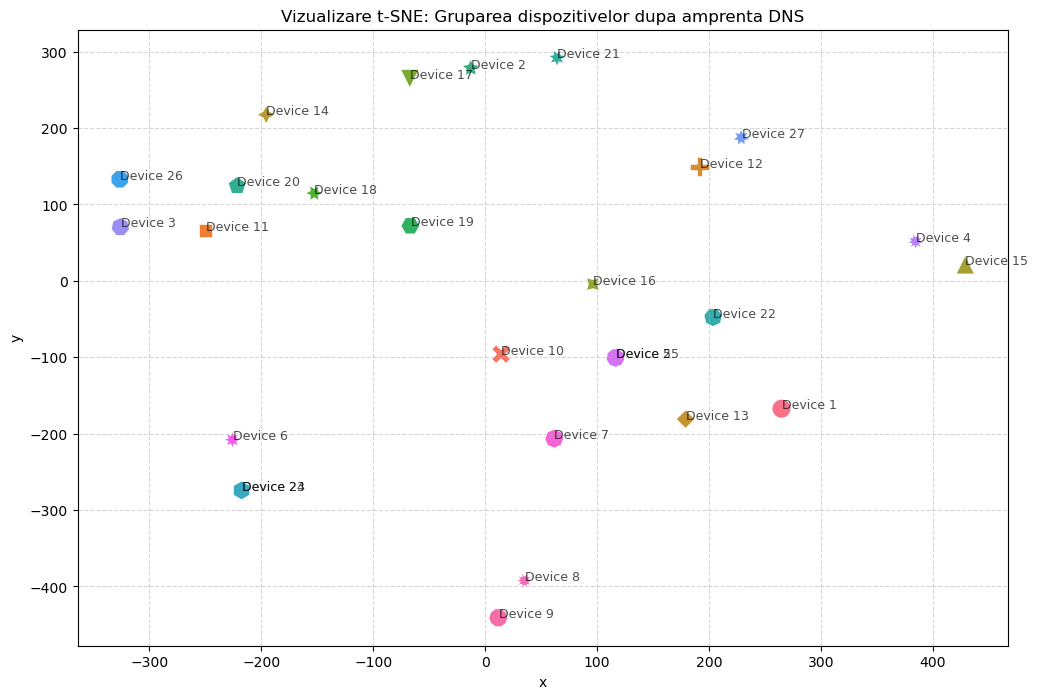

In [66]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aplicam t-SNE pe matricea de referinta
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X_reference.toarray())

# 2. Cream un DataFrame pentru plotare
tsne_df = pd.DataFrame({
    'x': X_embedded[:, 0],
    'y': X_embedded[:, 1],
    'device': devices_actually_tested
})

# 3. Vizualizare
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=tsne_df, 
    x='x', y='y', 
    hue='device', 
    style='device',
    s=200, # dimensiunea punctelor
    legend=False 
)

# Adaugam numele device-ului langa fiecare punct
for i in range(tsne_df.shape[0]):
    plt.text(
        tsne_df.x[i]+0.2, tsne_df.y[i]+0.2, 
        tsne_df.device[i], 
        fontsize=9, alpha=0.7
    )

plt.title("Vizualizare t-SNE: Gruparea dispozitivelor dupa amprenta DNS")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()